In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
import warnings
warnings.filterwarnings('ignore')

with open('model_artifacts.pkl', 'rb') as f:
    _art = pickle.load(f)

df         = _art['df']
results    = _art['results']
best_name  = _art['best_name']
best_model = _art['best_model']
scaler     = _art['scaler']
X_train    = _art['X_train']
X_train_sc = _art['X_train_sc']
X_test     = _art['X_test']
X_test_sc  = _art['X_test_sc']
y_train    = _art['y_train']
y_test     = _art['y_test']
Xtr_np     = _art['Xtr_np']
Xte_np     = _art['Xte_np']
risk_df    = _art['risk_df']

print(f"Loaded model artifacts — best model: {best_name}")
print(f"df shape: {df.shape}  |  Test: {X_test.shape}  |  High-risk employees: {(risk_df['RiskTier']=='High').sum()}")

Loaded model artifacts — best model: Logistic Regression
df shape: (1470, 69)  |  Test: (294, 67)  |  High-risk employees: 342


High-risk cohort : 342 employees
  Overtime workers     : 187  (54.7%)
  Travel_Frequently    : 96  (28.1%)  -> Travel_Rarely
  Travel_Rarely        : 230  (67.3%)  -> Non-Travel
  Non-Travel (no chg)  : 16  (4.7%)

Programme                          Ctrl    Trt  RelLift  ModelRR    p(z)   Sig
Retention Bonus                  77.8%  56.0%    28.0%    28.0%  0.0000   YES
Flexible / Hybrid Schedule       82.0%  59.8%    27.1%    24.0%  0.0000   YES
Reduced Overtime Policy          76.0%  60.0%    21.1%    25.4%  0.0007   YES
  ModelRR = relative reduction in model-predicted risk for treatment group


+-- Retention Bonus [SIG] -----------------------------------------+
  Description    : Financial incentive — 28% flat risk reduction (no feature analog in dataset)
  Model risk shift (treatment group)
    Before change : 0.803  |  After change : 0.579
    Model-level RR: 28.0%
  Observed sim rates
    Control 77.8%  ->  Treatment 56.0%
    Abs. reduction : 21.8%  (95% CI: [0.121, 0.315])  -

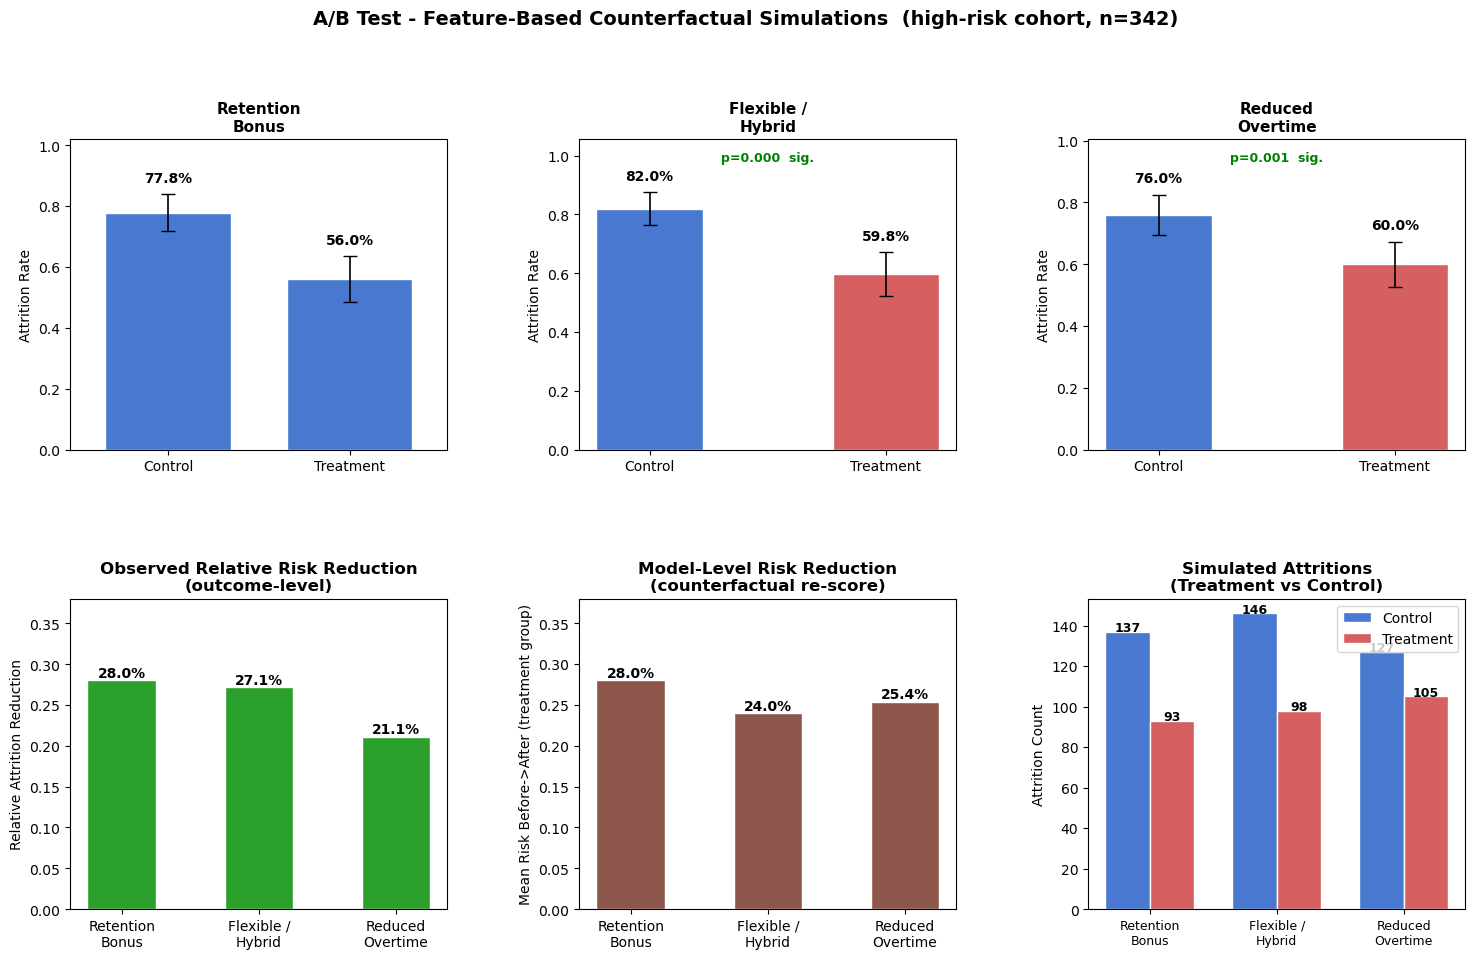

In [6]:
!pip install statsmodels -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize

ALPHA = 0.05

X_feat_all         = df.drop(columns=['Attrition', 'EmployeeNumber'], errors='ignore').copy()
X_feat_all.index   = df['EmployeeNumber'].values

def repredict(X):
    """Re-score a feature DataFrame through the best model."""
    if best_name == 'Logistic Regression':
        return best_model.predict_proba(scaler.transform(X.values))[:, 1]
    else:
        return best_model.predict_proba(X.values)[:, 1]

snap_cols = ['EmployeeNumber', 'OverTime',
             'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely']
high_risk_base = risk_df[risk_df['RiskTier'] == 'High'].copy().reset_index(drop=True)
hr = high_risk_base.merge(df[snap_cols], on='EmployeeNumber', how='left')
n  = len(hr)

n_ot   = int(hr['OverTime'].sum())
n_freq = int(hr['BusinessTravel_Travel_Frequently'].sum())
n_rare = int(((hr['BusinessTravel_Travel_Frequently'] == 0) &
              (hr['BusinessTravel_Travel_Rarely']     == 1)).sum())

print(f"High-risk cohort : {n} employees")
print(f"  Overtime workers     : {n_ot}  ({n_ot/n:.1%})")
print(f"  Travel_Frequently    : {n_freq}  ({n_freq/n:.1%})  -> Travel_Rarely")
print(f"  Travel_Rarely        : {n_rare}  ({n_rare/n:.1%})  -> Non-Travel")
print(f"  Non-Travel (no chg)  : {n-n_freq-n_rare}  ({(n-n_freq-n_rare)/n:.1%})\n")

def cf_overtime(X, t_mask):
    X = X.copy()
    affected = t_mask & (X['OverTime'] == 1)
    X.loc[affected, 'OverTime']                   = 0
    X.loc[affected, 'OvertimeFlag']               = 0
    X.loc[affected, 'OverTime_x_JobSatisfaction'] = 0
    return X

def cf_travel(X, t_mask):
    X = X.copy()
    was_freq = t_mask & (X['BusinessTravel_Travel_Frequently'] == 1)
    was_rare = t_mask & (X['BusinessTravel_Travel_Frequently'] == 0) & \
                         (X['BusinessTravel_Travel_Rarely']     == 1)
    X.loc[was_freq, 'BusinessTravel_Travel_Frequently'] = 0
    X.loc[was_freq, 'BusinessTravel_Travel_Rarely']     = 1
    X.loc[was_rare, 'BusinessTravel_Travel_Rarely']     = 0
    return X

programmes = {
    'Retention Bonus': {
        'desc': 'Financial incentive — 28% flat risk reduction (no feature analog in dataset)',
        'cf'  : False,
        'eff' : 0.28,
    },
    'Flexible / Hybrid Schedule': {
        'desc': 'Travel step-down: Frequent->Rarely, Rarely->Non-Travel; model re-scored',
        'cf'  : True,
        'fn'  : cf_travel,
    },
    'Reduced Overtime Policy': {
        'desc': 'OverTime=0 for OT workers in treatment group; interaction term zeroed; model re-scored',
        'cf'  : True,
        'fn'  : cf_overtime,
    },
}

ab_results = {}

for i, (prog, cfg) in enumerate(programmes.items()):
    np.random.seed(42 + i)

    sim            = hr.copy()
    sim['Group']   = np.where(np.random.rand(n) < 0.5, 'Treatment', 'Control')

    X_hr   = X_feat_all.loc[sim['EmployeeNumber'].values]
    base   = repredict(X_hr)

    t_mask = pd.Series(sim['Group'].values == 'Treatment', index=X_hr.index)

    if cfg['cf']:
        X_cf      = cfg['fn'](X_hr, t_mask)
        sim_risks = repredict(X_cf)
    else:
        sim_risks = np.where(t_mask.values,
                             base * (1 - cfg['eff']),
                             base)

    sim['SimRisk']      = sim_risks
    sim['SimAttrition'] = (np.random.rand(n) < sim['SimRisk']).astype(int)

    trt_rows         = t_mask.values.astype(bool)
    risk_before_mean = base[trt_rows].mean()
    risk_after_mean  = sim_risks[trt_rows].mean()
    model_rr         = (risk_before_mean - risk_after_mean) / risk_before_mean

    ctrl = sim[sim['Group'] == 'Control']
    trt  = sim[sim['Group'] == 'Treatment']
    p_c  = ctrl['SimAttrition'].mean()
    p_t  = trt['SimAttrition'].mean()
    abs_lift = p_c - p_t
    rel_lift = abs_lift / p_c if p_c > 0 else 0

    ct = pd.crosstab(sim['Group'], sim['SimAttrition'])
    chi2_stat, p_chi2, _, _ = stats.chi2_contingency(ct)
    z_stat, p_z = proportions_ztest(
        [trt['SimAttrition'].sum(), ctrl['SimAttrition'].sum()],
        [len(trt), len(ctrl)],
        alternative='smaller'
    )
    h       = proportion_effectsize(p_t, p_c)
    h_label = 'small' if abs(h) < 0.2 else ('medium' if abs(h) < 0.5 else 'large')
    se      = np.sqrt(p_t*(1-p_t)/len(trt) + p_c*(1-p_c)/len(ctrl))

    ab_results[prog] = dict(
        desc            = cfg['desc'],
        p_c             = p_c,   p_t  = p_t,
        abs_lift        = abs_lift,  rel_lift = rel_lift,
        ci_lo           = abs_lift - 1.96*se,
        ci_hi           = abs_lift + 1.96*se,
        chi2=chi2_stat, p_chi2=p_chi2,
        z=z_stat,       p_z=p_z,
        h=h,            h_label=h_label,
        sig             = (p_z < ALPHA),
        risk_before     = risk_before_mean,
        risk_after      = risk_after_mean,
        model_rr        = model_rr,
        sim             = sim,
    )

print("=" * 85)
print(f"{'Programme':<32} {'Ctrl':>6} {'Trt':>6} {'RelLift':>8} "
      f"{'ModelRR':>8} {'p(z)':>7} {'Sig':>5}")
print("=" * 85)
for prog, r in ab_results.items():
    print(f"{prog:<32} {r['p_c']:>5.1%}  {r['p_t']:>5.1%}  {r['rel_lift']:>7.1%}  "
          f"{r['model_rr']:>7.1%}  {r['p_z']:>6.4f}  {'YES' if r['sig'] else 'no':>4}")
print("=" * 85)
print("  ModelRR = relative reduction in model-predicted risk for treatment group\n")

# ── 7. Detailed results + interpretation ──────────────────────────────────────
for prog, r in ab_results.items():
    ci_note  = 'excludes 0 - effect is real' if r['ci_lo'] > 0 else 'includes 0 - effect uncertain'
    sig_note = (
        f"Significant (p={r['p_z']:.4f}). Feature change meaningfully shifts model risk.\n"
        f"  Rollout justified: ~{r['rel_lift']:.1%} fewer leavers in the treated cohort."
        if r['sig'] else
        f"Not significant (p={r['p_z']:.4f}). Cannot rule out chance at this cohort size.\n"
        f"  The feature change moves the needle (ModelRR={r['model_rr']:.1%}) but the\n"
        f"  random draw swamps the signal. Consider a larger cohort or longer window."
    )
    print(f"""
+-- {prog} {'[SIG]' if r['sig'] else '[n.s]'} {'-' * (56 - len(prog))}+
  Description    : {r['desc']}
  Model risk shift (treatment group)
    Before change : {r['risk_before']:.3f}  |  After change : {r['risk_after']:.3f}
    Model-level RR: {r['model_rr']:.1%}
  Observed sim rates
    Control {r['p_c']:.1%}  ->  Treatment {r['p_t']:.1%}
    Abs. reduction : {r['abs_lift']:.1%}  (95% CI: [{r['ci_lo']:.3f}, {r['ci_hi']:.3f}])  - {ci_note}
    Rel. reduction : {r['rel_lift']:.1%}
  Tests
    Chi-squared p  : {r['p_chi2']:.4f}   |   Z-test p : {r['p_z']:.4f} (one-sided)
    Cohen h        : {r['h']:.3f}  ({r['h_label']} effect)
  Verdict : {sig_note}
""")

prog_names  = list(ab_results.keys())
short_names = ['Retention\nBonus', 'Flexible /\nHybrid', 'Reduced\nOvertime']
c_ctrl, c_trt = '#4878CF', '#D65F5F'

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)

for col, (prog, r) in enumerate(ab_results.items()):
    ax     = fig.add_subplot(gs[0, col])
    rates  = [r['p_c'], r['p_t']]
    n_ctrl = (r['sim']['Group'] == 'Control').sum()
    n_trt  = (r['sim']['Group'] == 'Treatment').sum()
    ci_err = [1.96*np.sqrt(r['p_c']*(1-r['p_c'])/n_ctrl),
              1.96*np.sqrt(r['p_t']*(1-r['p_t'])/n_trt)]
    _x   = [0, 0.65] if col == 0 else ['Control', 'Treatment']
    _clr = [c_ctrl, c_ctrl] if col == 0 else [c_ctrl, c_trt]
    bars = ax.bar(_x, rates, color=_clr, edgecolor='white', width=0.45,
                  yerr=ci_err, capsize=5, error_kw={'ecolor':'k','lw':1.2})
    if col == 0:
        ax.set_xticks([0, 0.65])
        ax.set_xticklabels(['Control', 'Treatment'])
        ax.set_xlim(-0.35, 1.0)
    for bar, rate, err in zip(bars, rates, ci_err):
        ax.text(bar.get_x() + bar.get_width()/2, rate + err + 0.04,
                f'{rate:.1%}', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(short_names[col], fontweight='bold', fontsize=11)
    ax.set_ylabel('Attrition Rate')
    ax.set_ylim(0, max(rt + e for rt, e in zip(rates, ci_err)) + 0.18)
    if col != 0:
        ax.annotate(f"p={r['p_z']:.3f}  {'sig.' if r['sig'] else 'n.s.'}",
                    xy=(0.5, 0.93), xycoords='axes fraction', ha='center',
                    fontsize=9, color='green' if r['sig'] else 'red', fontweight='bold')

ax_lift = fig.add_subplot(gs[1, 0])
rl = [r['rel_lift'] for r in ab_results.values()]
bar_clr = ['#2ca02c' if r['sig'] else '#aec7e8' for r in ab_results.values()]
bars = ax_lift.bar(short_names, rl, color=bar_clr, edgecolor='white', width=0.5)
for bar, v in zip(bars, rl):
    ax_lift.text(bar.get_x() + bar.get_width()/2, v + 0.004,
                 f'{v:.1%}', ha='center', fontweight='bold', fontsize=10)
ax_lift.set_title('Observed Relative Risk Reduction\n(outcome-level)', fontweight='bold')
ax_lift.set_ylabel('Relative Attrition Reduction')
ax_lift.set_ylim(0, max(rl) + 0.10)

ax_mr = fig.add_subplot(gs[1, 1])
mr = [r['model_rr'] for r in ab_results.values()]
bars = ax_mr.bar(short_names, mr, color='#8c564b', edgecolor='white', width=0.5)
for bar, v in zip(bars, mr):
    ax_mr.text(bar.get_x() + bar.get_width()/2, v + 0.004,
               f'{v:.1%}', ha='center', fontweight='bold', fontsize=10)
ax_mr.set_title("Model-Level Risk Reduction\n(counterfactual re-score)", fontweight='bold')
ax_mr.set_ylabel("Mean Risk Before->After (treatment group)")
ax_mr.set_ylim(0, max(mr) + 0.10)

ax_cnt = fig.add_subplot(gs[1, 2])
x     = np.arange(len(prog_names))
w     = 0.35
c_att = [r['sim'][r['sim']['Group']=='Control']['SimAttrition'].sum()
         for r in ab_results.values()]
t_att = [r['sim'][r['sim']['Group']=='Treatment']['SimAttrition'].sum()
         for r in ab_results.values()]
ax_cnt.bar(x - w/2, c_att, w, label='Control',   color=c_ctrl, edgecolor='white')
ax_cnt.bar(x + w/2, t_att, w, label='Treatment', color=c_trt,  edgecolor='white')
for j, (cv, tv) in enumerate(zip(c_att, t_att)):
    ax_cnt.text(j - w/2, cv + .2, str(cv), ha='center', fontsize=9, fontweight='bold')
    ax_cnt.text(j + w/2, tv + .2, str(tv), ha='center', fontsize=9, fontweight='bold')
ax_cnt.set_xticks(x)
ax_cnt.set_xticklabels(short_names, fontsize=9)
ax_cnt.set_title('Simulated Attritions\n(Treatment vs Control)', fontweight='bold')
ax_cnt.set_ylabel('Attrition Count')
ax_cnt.legend()

fig.suptitle(
    f'A/B Test - Feature-Based Counterfactual Simulations  (high-risk cohort, n={n})',
    fontsize=14, fontweight='bold', y=1.01
)
plt.show()

In [5]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import pandas as pd
import numpy as np

alpha        = 0.05
power_target = 0.80
analysis     = NormalIndPower()

power_table = []

for prog, r in ab_results.items():
    p_control = r['p_c']
    p_treat   = r['p_t']

    effect_size = proportion_effectsize(p_treat, p_control)

    n_per_group = analysis.solve_power(
        effect_size=abs(effect_size),
        power=power_target,
        alpha=alpha,
        ratio=1.0,
        alternative='two-sided'
    )

    total_n = np.ceil(n_per_group * 2)

    power_table.append({
        "Programme"              : prog,
        "Control Rate"           : round(p_control, 3),
        "Treatment Rate"         : round(p_treat, 3),
        "Abs Reduction"          : round(p_control - p_treat, 3),
        "Rel Reduction"          : round((p_control - p_treat) / p_control, 3),
        "Cohen_h"                : round(effect_size, 3),
        "n per group (80% power)": int(np.ceil(n_per_group)),
        "Total n required"       : int(total_n)
    })

power_df = pd.DataFrame(power_table)
power_df

,Programme,Control Rate,Treatment Rate,Abs Reduction,Rel Reduction,Cohen_h,n per group (80% power),Total n required
0,Retention Bonus,0.778,0.560,0.218,0.280,-0.470,72,143
1,Flexible / Hybrid Schedule,0.820,0.598,0.223,0.271,-0.499,64,127
2,Reduced Overtime Policy,0.760,0.600,0.160,0.211,-0.347,131,262
